In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

# load clean data

In [2]:
df = pd.read_csv(
    "../data/processed/cleaned_data.csv"
)

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Fname,Customer Id,Customer Lname,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode,Customer_Full_Name,Profit_Margin,Shipping_Delay,Discount_Bucket,Profitability_Class,Customer_Value_Index,Revenue_Tier,Margin_Category
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,EE. UU.,Richard,1,Hernandez,Consumer,TX,6303 Heather Plaza,78521.0,3,Footwear,25.953648,-97.507683,Pacific Asia,Mumbai,India,1,27.50,0.06,99.99,0.34,5,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class,Richard Hernandez,31.941194,2,5-10%,1,159.69,High,High Margin
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,5,Golf,38.375595,-104.726021,LATAM,San Pedro Sula,Honduras,2,31.99,0.16,39.99,0.29,5,199.95,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class,Mary Barrett,24.361090,0,15-20%,1,208.74,Medium,High Margin
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,7,Fan Shop,38.375595,-104.726021,LATAM,San Pedro Sula,Honduras,2,18.00,0.09,199.99,0.48,1,199.99,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class,Mary Barrett,43.682184,0,5-10%,1,208.74,Medium,High Margin
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,7,Fan Shop,38.375595,-104.726021,USCA,New York City,Estados Unidos,2,24.00,0.12,199.99,-0.24,1,199.99,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class,Mary Barrett,-20.946047,2,10-15%,0,208.74,Medium,Loss Making
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,5,Golf,38.375595,-104.726021,USCA,New York City,Estados Unidos,2,10.00,0.20,50.00,0.25,1,50.00,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class,Mary Barrett,20.000000,2,15-20%,1,208.74,Low,High Margin


# REVENUE & PROFIT ANALYSIS

# Total Revenue

In [3]:
total_revenue = df["Sales"].sum()

print(f"Revenue: ${total_revenue:,.2f}")

Revenue: $36,784,734.31


# Total Profit

In [4]:
total_profit = df["Order Profit Per Order"].sum()

print(f"Profit: ${total_profit:,.2f}")

Profit: $3,966,902.97


# Profit Margin

In [5]:
profit_margin = (
    total_profit /
    total_revenue
) * 100

print(
    f"Profit Margin: {profit_margin:.2f}%"
)

Profit Margin: 10.78%


# Revenue vs Profit 

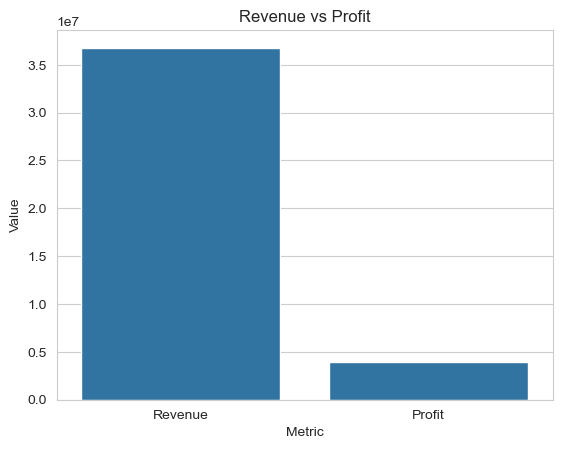

In [6]:
metrics = pd.DataFrame({
    "Metric":["Revenue","Profit"],
    "Value":[
        total_revenue,
        total_profit
    ]
})

sns.barplot(
    data=metrics,
    x="Metric",
    y="Value"
)

plt.title(
    "Revenue vs Profit"
)

plt.show()

# CUSTOMER ANALYSIS

# Top 10 Customers by Profit

In [9]:
top_customers = (
    df.groupby(
        "Customer Id"
    )
    ["Order Profit Per Order"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

top_customers

Customer Id
2641     2441.97
1657     2196.92
9833     1938.39
2626     1928.57
5004     1917.99
3735     1906.36
749      1855.15
5560     1831.46
10967    1822.33
5053     1813.34
Name: Order Profit Per Order, dtype: float64

# Visualization

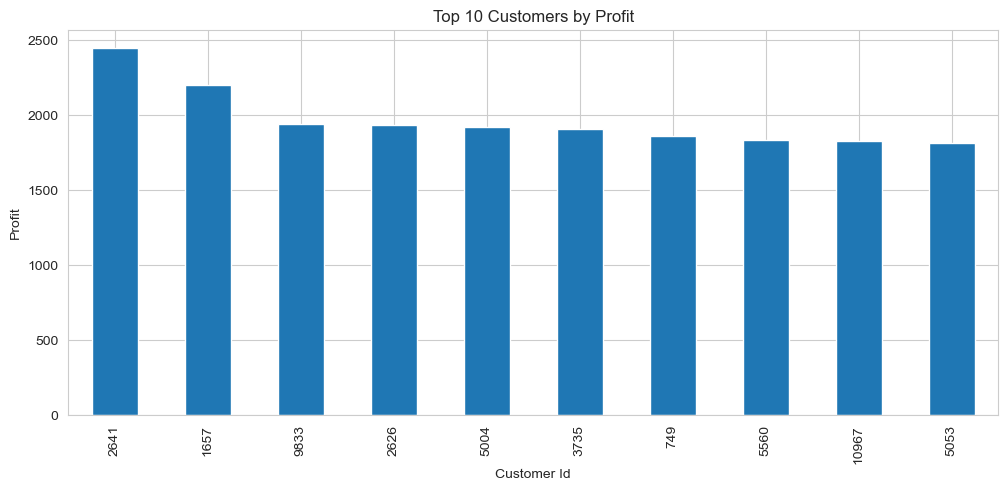

In [10]:
top_customers.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title(
    "Top 10 Customers by Profit"
)

plt.ylabel("Profit")

plt.show()

# Bottom 10 customers 

In [11]:
bottom_customers = (
    df.groupby(
        "Customer Id"
    )
    ["Order Profit Per Order"]
    .sum()
    .sort_values()
    .head(10)
)

bottom_customers

Customer Id
1428    -3868.56
14086   -3442.50
18109   -3366.00
14313   -3000.00
18061   -2592.00
14113   -2550.00
14090   -2351.25
14398   -2328.00
14306   -2280.00
14236   -2255.25
Name: Order Profit Per Order, dtype: float64

# CUSTOMER SEGMENT ANALYSIS

In [12]:
segment_analysis = (
    df.groupby(
        "Customer Segment"
    )
    .agg({
        "Sales":"sum",
        "Order Profit Per Order":"sum"
    })
)

segment_analysis

,Sales,Order Profit Per Order
Customer Segment,,
Consumer,19095789.79,2073487.67
Corporate,11168406.63,1202574.96
Home Office,6520537.89,690840.34


# Visualization

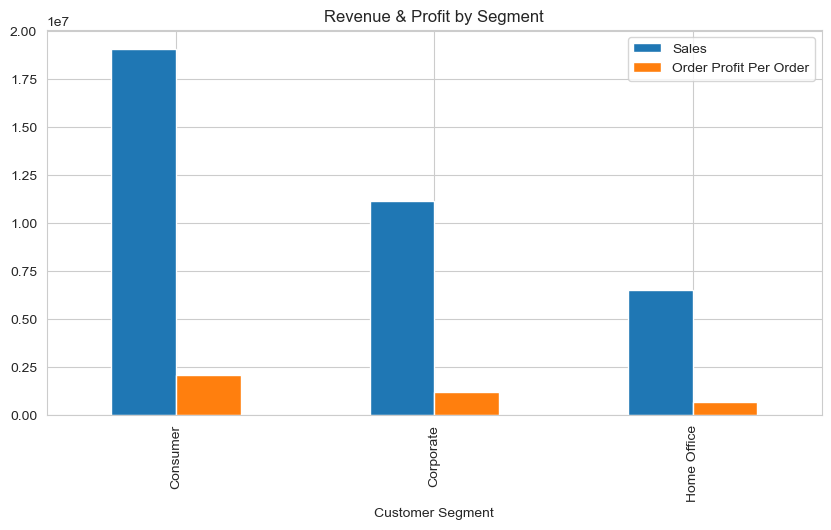

In [13]:
segment_analysis.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Revenue & Profit by Segment"
)

plt.show()

# PRODUCT PROFITABILITY ANALYSIS

# Category Performance

In [14]:
category_analysis = (
    df.groupby(
        "Category Name"
    )
    .agg({
        "Sales":"sum",
        "Order Profit Per Order":"sum"
    })
    .reset_index()
)

category_analysis["Margin"] = (
    category_analysis[
        "Order Profit Per Order"
    ]
    /
    category_analysis["Sales"]
) * 100

category_analysis.head()

,Category Name,Sales,Order Profit Per Order,Margin
0,Accessories,133671.51,16643.52,12.451060
1,As Seen on TV!,20597.94,714.43,3.468454
2,Baby,12229.56,1525.03,12.470032
3,Baseball & Softball,94057.15,12762.13,13.568485
4,Basketball,27099.33,1845.67,6.810759


# Top Categories

In [16]:
top_categories = (
    category_analysis
    .sort_values(
        "Order Profit Per Order",
        ascending=False
    )
    .head(10)
)

top_categories

,Category Name,Sales,Order Profit Per Order,Margin
18,Fishing,6929653.50,756220.76,10.912822
12,Cleats,4431942.66,494636.92,11.160725
9,Camping & Hiking,4118425.42,427455.57,10.379102
10,Cardio Equipment,3694843.20,383011.10,10.366099
47,Women's Apparel,3147800.00,350421.03,11.132252
46,Water Sports,3113844.60,325146.96,10.441978
30,Indoor/Outdoor Games,2888993.94,318451.43,11.022918
34,Men's Footwear,2891757.54,311902.82,10.785926
38,Shop By Sport,1309522.02,129813.96,9.913080
13,Computers,663000.00,69656.81,10.506306


# Visualization

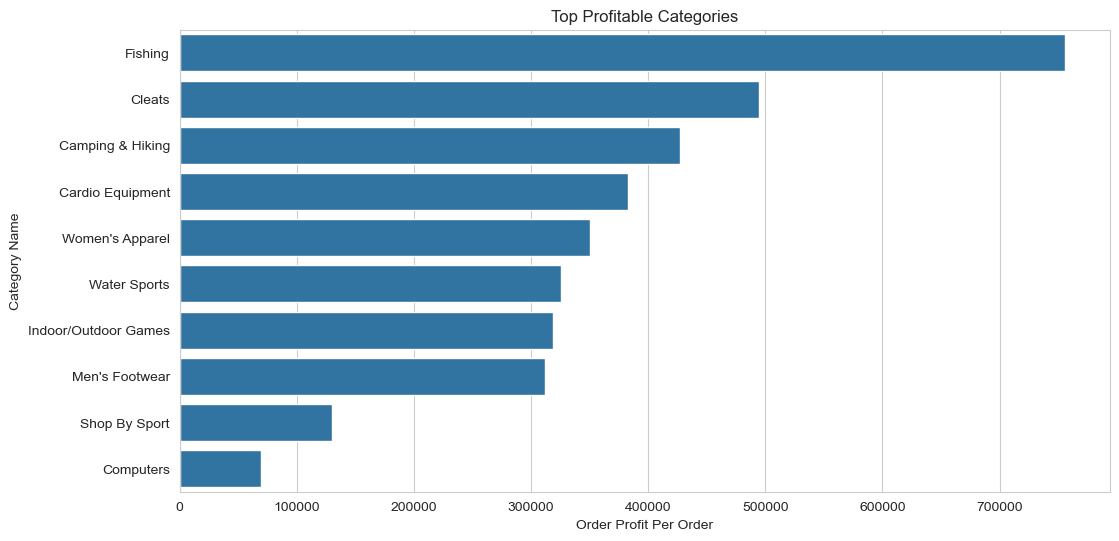

In [17]:
plt.figure(
    figsize=(12,6)
)

sns.barplot(
    data=top_categories,
    x="Order Profit Per Order",
    y="Category Name"
)

plt.title(
    "Top Profitable Categories"
)

plt.show()

# LOSS MAKING CATEGORIES

In [18]:
loss_categories = (
    category_analysis[
        category_analysis[
            "Order Profit Per Order"
        ] < 0
    ]
)

loss_categories

,Category Name,Sales,Order Profit Per Order,Margin


# PRODUCT ANALYSIS

# Top Products by Profit

In [19]:
product_profit = (
    df.groupby(
        "Product Name"
    )
    ["Order Profit Per Order"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(20)
)

product_profit

Product Name
Field & Stream Sportsman 16 Gun Fire Safe        756220.76
Perfect Fitness Perfect Rip Deck                 493828.30
Diamondback Women's Serene Classic Comfort Bi    427455.57
Nike Men's Free 5.0+ Running Shoe                379915.82
Nike Men's Dri-FIT Victory Golf Polo             350421.03
Pelican Sunstream 100 Kayak                      324076.37
O'Brien Men's Neoprene Life Vest                 318451.43
Nike Men's CJ Elite 2 TD Football Cleat          311902.82
Under Armour Girls' Toddler Spine Surge Runni    126278.51
Dell Laptop                                       69656.81
Lawn mower                                        33443.01
Web Camera                                        30289.80
Children's heaters                                27178.10
Porcelain crafts                                  25531.17
Summer dresses                                    19102.85
Rock music                                        14436.32
Industrial consumer electronics            

# Visualization 

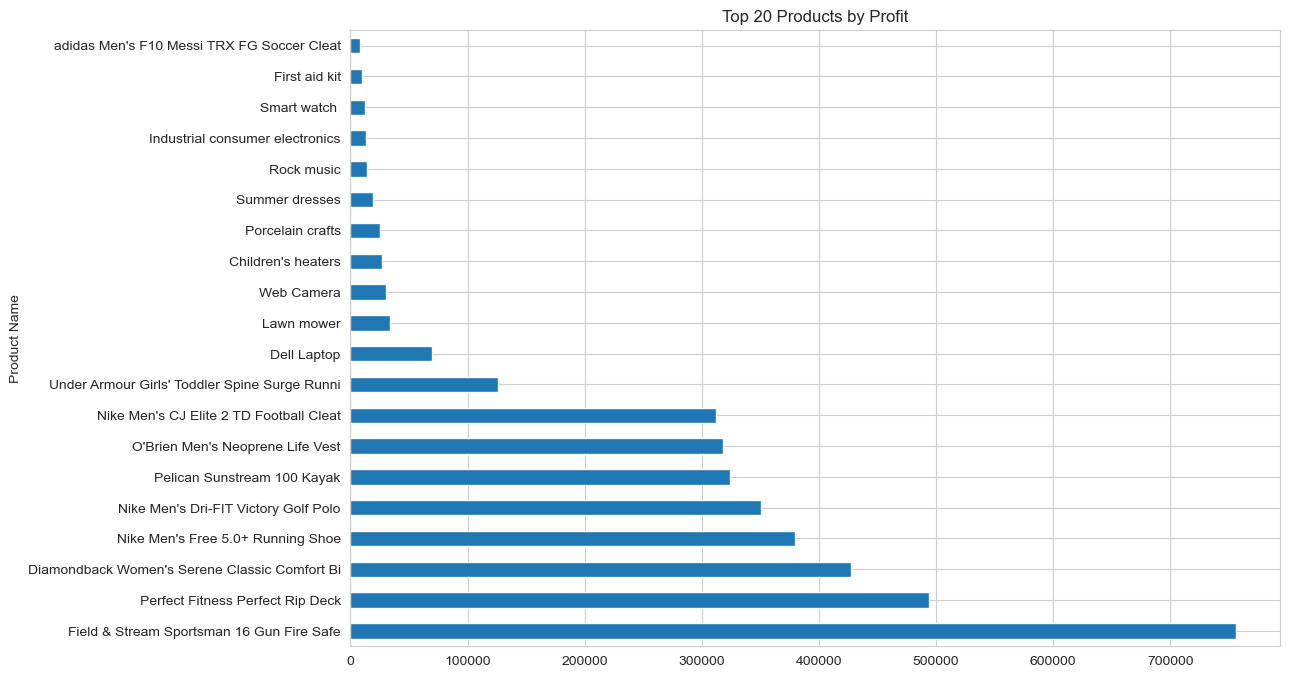

In [20]:
product_profit.plot(
    kind="barh",
    figsize=(12,8)
)

plt.title(
    "Top 20 Products by Profit"
)

plt.show()

# DISCOUNT IMPACT ANALYSIS

# Discount Bucket Analysis

In [21]:
discount_analysis = (
    df.groupby(
        "Discount_Bucket"
    )
    .agg({
        "Order Profit Per Order":"mean",
        "Profit_Margin":"mean"
    })
)

discount_analysis

,Order Profit Per Order,Profit_Margin
Discount_Bucket,,
0-5%,23.916745,11.885389
10-15%,20.784363,10.201223
15-20%,19.544845,9.602463
20%+,19.134183,9.522186
5-10%,23.095813,11.284822


# Visualization

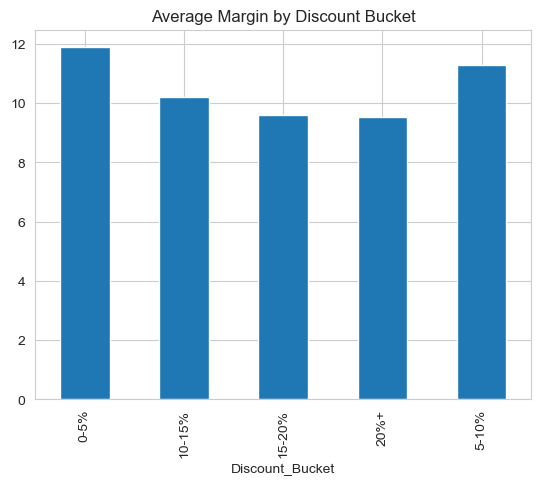

In [22]:
discount_analysis[
    "Profit_Margin"
].plot(
    kind="bar"
)

plt.title(
    "Average Margin by Discount Bucket"
)

plt.show()

# Discount vs Profit Scatter Plot

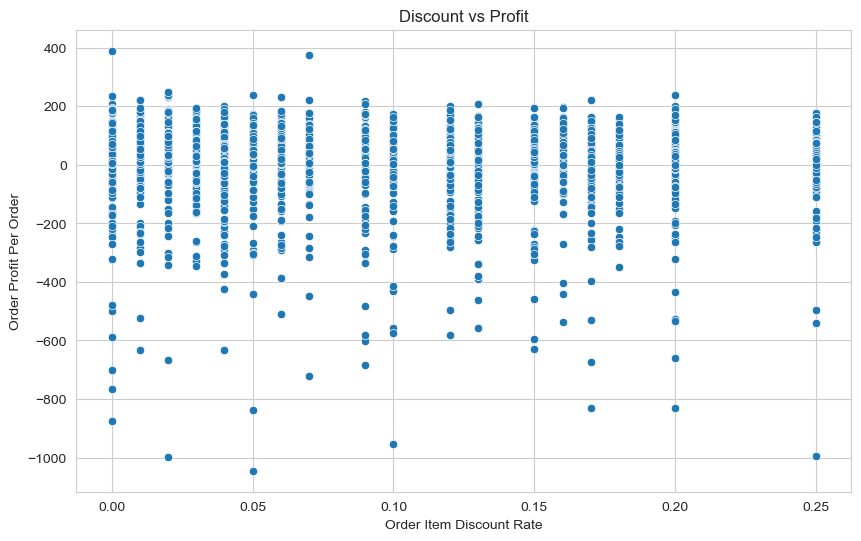

In [23]:
plt.figure(
    figsize=(10,6)
)

sns.scatterplot(
    data=df.sample(
        5000,
        random_state=42
    ),
    x="Order Item Discount Rate",
    y="Order Profit Per Order"
)

plt.title(
    "Discount vs Profit"
)

plt.show()

# MARKET ANALYSIS

# Market Revenue & Profit

In [24]:
market_analysis = (
    df.groupby(
        "Market"
    )
    .agg({
        "Sales":"sum",
        "Order Profit Per Order":"sum"
    })
    .reset_index()
)

market_analysis

,Market,Sales,Order Profit Per Order
0,Africa,2294452.88,252071.18
1,Europe,10872396.60,1169442.96
2,LATAM,10277612.64,1123321.61
3,Pacific Asia,8273743.58,857753.44
4,USCA,5066528.61,564313.78


# Market margin

In [25]:
market_analysis["Margin"] = (
    market_analysis[
        "Order Profit Per Order"
    ]
    /
    market_analysis["Sales"]
) * 100

market_analysis

,Market,Sales,Order Profit Per Order,Margin
0,Africa,2294452.88,252071.18,10.986113
1,Europe,10872396.60,1169442.96,10.756073
2,LATAM,10277612.64,1123321.61,10.929791
3,Pacific Asia,8273743.58,857753.44,10.367175
4,USCA,5066528.61,564313.78,11.138075


# Visualization

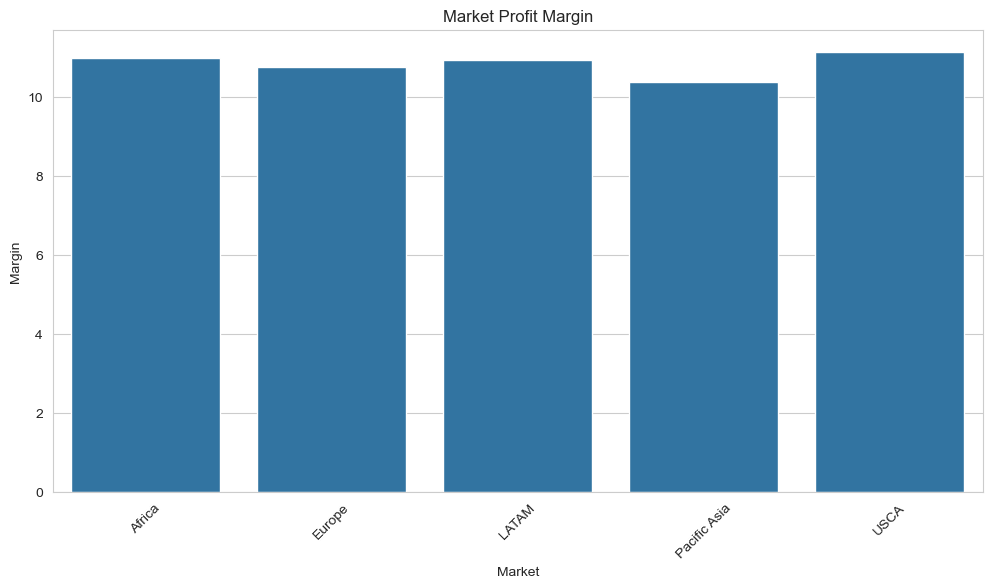

In [26]:
plt.figure(
    figsize=(12,6)
)

sns.barplot(
    data=market_analysis,
    x="Market",
    y="Margin"
)

plt.title(
    "Market Profit Margin"
)

plt.xticks(
    rotation=45
)

plt.show()

# REGION ANALYSIS

In [27]:
region_analysis = (
    df.groupby(
        "Order Region"
    )
    .agg({
        "Sales":"sum",
        "Order Profit Per Order":"sum"
    })
    .reset_index()
)

region_analysis.head()

,Order Region,Sales,Order Profit Per Order
0,Canada,186861.04,23900.71
1,Caribbean,1651019.30,171825.64
2,Central Africa,327263.01,33447.27
3,Central America,5665711.99,616341.57
4,Central Asia,109839.93,13045.28


# HEATMAP

# Category Margin Heatmap

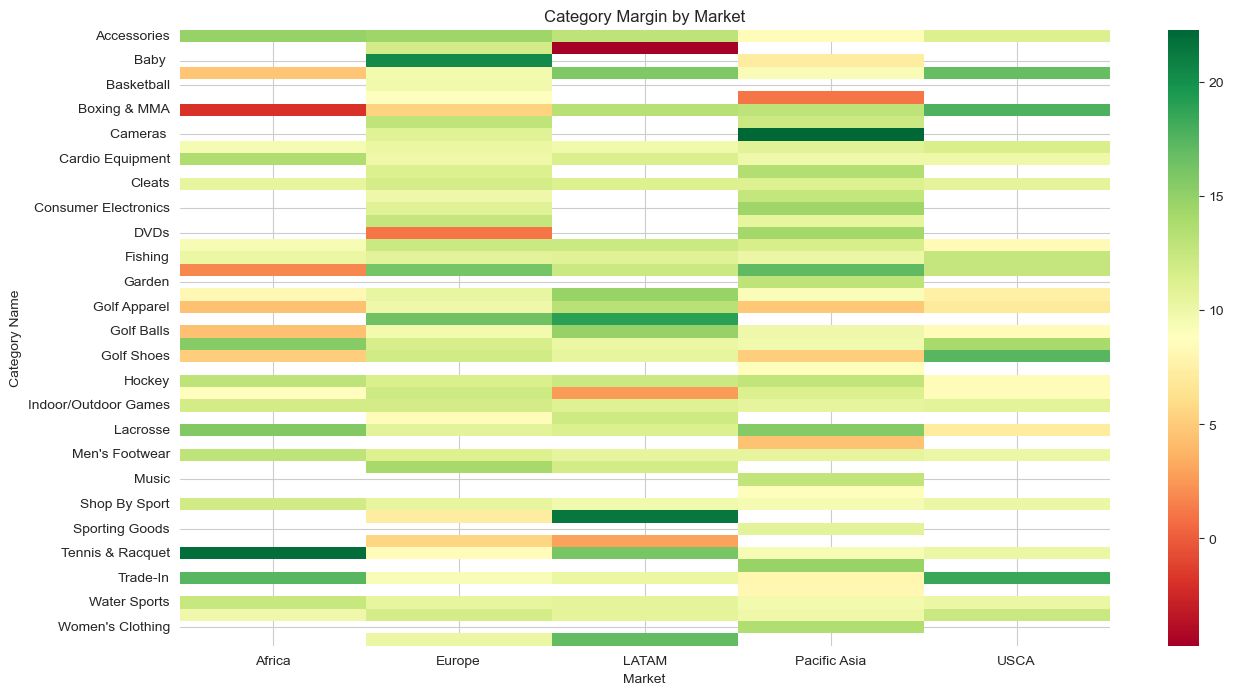

In [28]:
heatmap_data = (
    df.pivot_table(
        values="Profit_Margin",
        index="Category Name",
        columns="Market",
        aggfunc="mean"
    )
)

plt.figure(
    figsize=(15,8)
)

sns.heatmap(
    heatmap_data,
    cmap="RdYlGn",
    annot=False
)

plt.title(
    "Category Margin by Market"
)

plt.show()

# Executive Insights

## Customer Insights

- Top customers contribute disproportionate share of profit.
- Several customers generate revenue but destroy margins.

## Product Insights

- Certain categories dominate profitability.
- Some products have high sales but weak margins.

## Discount Insights

- Higher discounts lead to lower profit margins.
- Discount governance policy is recommended.

## Market Insights

- Europe and LATAM generate highest profits.
- Some markets show strong revenue but lower efficiency.

## Business Recommendations

1. Retain top profitable customers.
2. Revisit pricing for low-margin products.
3. Restrict excessive discounts.
4. Expand investment in profitable markets.
5. Deploy ML model to predict order profitability.